# RQ2: Fine-Tuning YOLOv8n on Newcastle CCTV
**Author:** Sumit Malviya (W24041293) | **Supervisor:** Dr. Jason Moore | **Module:** KF7029

**RQ2:** Does fine-tuning YOLOv8n on Newcastle-specific data improve detection performance?

This notebook does EVERYTHING:
1. Prepares the data.yaml with correct paths
2. **Trains/fine-tunes YOLOv8n** for 50 epochs (~40 mins on CPU)
3. Evaluates both baseline and fine-tuned models
4. Generates before vs after comparison charts

---

## 1. Setup

In [1]:
print("⏳ Step X: [description]...")
import os, csv, time, yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import defaultdict
from pathlib import Path
from ultralytics import YOLO

matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================
# CONFIGURATION
# ============================================================
BASELINE_MODEL = '../yolov8n.pt'
GT_DIR = Path('../data/ground_truth_roboflow').resolve()
RESULTS_DIR = '../data/results'
CONF = 0.25; IOU = 0.5; DEVICE = 'cpu'; IMGSZ = 640
MIN_AREA = 0.001  # Small+ filter for evaluation

# Training config
EPOCHS = 50
BATCH_SIZE = 8  # Reduce to 4 if memory error
RUN_NAME = 'newcastle_finetune'

COCO_TO_RF = {9:0, 5:1, 2:2, 0:3, 7:4}
RF_NAMES = {0:'Traffic light', 1:'Bus', 2:'Car', 3:'Person', 4:'Truck'}
os.makedirs(RESULTS_DIR, exist_ok=True)

print('='*60)
print('  RQ2: FINE-TUNING & COMPARISON')
print('='*60)
print(f'  Baseline:    {BASELINE_MODEL}')
print(f'  Dataset:     {GT_DIR}')
print(f'  Epochs:      {EPOCHS}')
print(f'  Batch size:  {BATCH_SIZE}')
print(f'  Device:      {DEVICE}')
print('='*60)

⏳ Step X: [description]...
  RQ2: FINE-TUNING & COMPARISON
  Baseline:    ../yolov8n.pt
  Dataset:     /Users/cashify/Downloads/Assignments(INTERSHIP)/MSC PROJECT(DISERTATION)/project/urban-digital-twin-backend/data/ground_truth_roboflow
  Epochs:      50
  Batch size:  8
  Device:      cpu


## 2. Prepare data.yaml for Training

In [2]:
# Read existing data.yaml and update paths to absolute
data_yaml = GT_DIR / 'data.yaml'
with open(data_yaml) as f:
    config = yaml.safe_load(f)

config['train'] = str(GT_DIR / 'train' / 'images')
config['val'] = str(GT_DIR / 'valid' / 'images')
if (GT_DIR / 'test' / 'images').exists():
    config['test'] = str(GT_DIR / 'test' / 'images')

updated_yaml = GT_DIR / 'data_finetune.yaml'
with open(updated_yaml, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print(f'Updated data.yaml saved to: {updated_yaml}')
print(f'  Train: {config["train"]}')
print(f'  Val:   {config["val"]}')
print(f'  Classes: {config["nc"]} — {config["names"]}')

Updated data.yaml saved to: /Users/cashify/Downloads/Assignments(INTERSHIP)/MSC PROJECT(DISERTATION)/project/urban-digital-twin-backend/data/ground_truth_roboflow/data_finetune.yaml
  Train: /Users/cashify/Downloads/Assignments(INTERSHIP)/MSC PROJECT(DISERTATION)/project/urban-digital-twin-backend/data/ground_truth_roboflow/train/images
  Val:   /Users/cashify/Downloads/Assignments(INTERSHIP)/MSC PROJECT(DISERTATION)/project/urban-digital-twin-backend/data/ground_truth_roboflow/valid/images
  Classes: 5 — ['Traffic light', 'bus', 'car', 'person', 'truck']


## 3. 🚀 Fine-Tune YOLOv8n (Training Cell)
**This cell takes ~40-60 minutes on CPU.** You'll see progress bars for each epoch.

If you've already trained and have `best.pt`, you can **skip this cell** and go to Cell 4.

In [3]:
# ============================================================
# FINE-TUNING — 50 EPOCHS
# ============================================================
# Skip this cell if you already have runs/detect/newcastle_finetune/weights/best.pt

print('Loading pre-trained YOLOv8n...')
model_train = YOLO(BASELINE_MODEL)

print(f'Starting fine-tuning for {EPOCHS} epochs...\n')
train_results = model_train.train(
    data=str(updated_yaml),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH_SIZE,
    device=DEVICE,
    name=RUN_NAME,
    patience=15,
    save=True,
    plots=True,
    verbose=True,
    
    # Optimised hyperparameters for small dataset
    lr0=0.001,
    lrf=0.01,
    warmup_epochs=5,
    warmup_momentum=0.5,
    weight_decay=0.001,
    
    # Augmentation
    hsv_h=0.015, hsv_s=0.5, hsv_v=0.3,
    degrees=5.0, translate=0.1, scale=0.3,
    flipud=0.0, fliplr=0.5,
    mosaic=0.8, mixup=0.1,
)

print('\n' + '='*60)
print('  TRAINING COMPLETE!')
print(f'  Best model: runs/detect/{RUN_NAME}/weights/best.pt')
print('='*60)

Loading pre-trained YOLOv8n...
Starting fine-tuning for 50 epochs...

New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.0 🚀 Python-3.12.7 torch-2.2.2 CPU (Intel Core(TM) i7-9750H 2.60GHz)
engine/trainer: task=detect, mode=train, model=../yolov8n.pt, data=/Users/cashify/Downloads/Assignments(INTERSHIP)/MSC PROJECT(DISERTATION)/project/urban-digital-twin-backend/data/ground_truth_roboflow/data_finetune.yaml, epochs=50, time=None, patience=15, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=cpu, workers=8, project=None, name=newcastle_finetune2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, 

train: Scanning /Users/cashify/Downloads/Assignments(INTERSHIP)/MSC PROJECT(DISERTATION)/project/urban-digital-twin-backend/data/ground_truth_roboflow/train/labels.cache... 104 images, 3 backgrounds, 0 corrupt: 100%|██████████| 104/104 [00:00<?, ?it/s]

train: WARNING ⚠️ /Users/cashify/Downloads/Assignments(INTERSHIP)/MSC PROJECT(DISERTATION)/project/urban-digital-twin-backend/data/ground_truth_roboflow/train/images/Finchale_Rd_Fram_Moor_Salutation_Rbt_20260311_123013_jpg.rf.ddca66d70b110820be9c8f5a1ff7b027.jpg: 1 duplicate labels removed



val: Scanning /Users/cashify/Downloads/Assignments(INTERSHIP)/MSC PROJECT(DISERTATION)/project/urban-digital-twin-backend/data/ground_truth_roboflow/valid/labels.cache... 19 images, 0 backgrounds, 0 corrupt: 100%|██████████| 19/19 [00:00<?, ?it/s]


Plotting labels to /Users/cashify/Downloads/Assignments(INTERSHIP)/MSC PROJECT(DISERTATION)/project/urban-digital-twin-backend/runs/detect/newcastle_finetune2/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.001' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.001), 63 bias(decay=0.0)
50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      50/50         0G      1.172      1.031     0.9242         70        640: 100%|██████████| 13/13 [00:41<00:00,  3.20s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:03<00:00,  1.54s/it]

                   all         19        304       0.34      0.294      0.305      0.197



50 epochs completed in 0.659 hours.
Optimizer stripped from /Users/cashify/Downloads/Assignments(INTERSHIP)/MSC PROJECT(DISERTATION)/project/urban-digital-twin-backend/runs/detect/newcastle_finetune2/weights/last.pt, 6.3MB
Optimizer stripped from /Users/cashify/Downloads/Assignments(INTERSHIP)/MSC PROJECT(DISERTATION)/project/urban-digital-twin-backend/runs/detect/newcastle_finetune2/weights/best.pt, 6.3MB

Validating /Users/cashify/Downloads/Assignments(INTERSHIP)/MSC PROJECT(DISERTATION)/project/urban-digital-twin-backend/runs/detect/newcastle_finetune2/weights/best.pt...
Ultralytics YOLOv8.1.0 🚀 Python-3.12.7 torch-2.2.2 CPU (Intel Core(TM) i7-9750H 2.60GHz)
Model summary (fused): 168 layers, 3006623 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:02<00:00,  1.27s/it]


                   all         19        304      0.451      0.305       0.32      0.212
         Traffic light         19         38      0.447      0.132       0.18     0.0728
                   bus         19          3          0          0     0.0163    0.00958
                   car         19        247      0.579      0.741      0.731      0.436
                person         19         12       0.23      0.167      0.108     0.0719
                 truck         19          4          1      0.484      0.564      0.468
Speed: 4.6ms preprocess, 114.3ms inference, 0.0ms loss, 7.8ms postprocess per image
Results saved to /Users/cashify/Downloads/Assignments(INTERSHIP)/MSC PROJECT(DISERTATION)/project/urban-digital-twin-backend/runs/detect/newcastle_finetune2

  TRAINING COMPLETE!
  Best model: runs/detect/newcastle_finetune/weights/best.pt


## 4. Load Both Models for Comparison

In [16]:
# Find the fine-tuned model
%matplotlib inline
ft_path = f'../runs/detect/{RUN_NAME}/weights/best.pt'
if not os.path.exists(ft_path):
    # Check alternative paths
    for p in [f'runs/detect/{RUN_NAME}/weights/best.pt',
              f'../runs/detect/{RUN_NAME}2/weights/best.pt']:
        if os.path.exists(p): ft_path = p; break

print(f'Loading baseline model: {BASELINE_MODEL}')
baseline = YOLO(BASELINE_MODEL)
print(f'Loading fine-tuned model: {ft_path}')
finetuned = YOLO(ft_path)
print('Both models loaded.')

Loading baseline model: ../yolov8n.pt
Loading fine-tuned model: ../runs/detect/newcastle_finetune/weights/best.pt
Both models loaded.


## 5. Helper Functions

In [17]:
def compute_iou(b1, b2):
    x1=max(b1[0]-b1[2]/2,b2[0]-b2[2]/2); y1=max(b1[1]-b1[3]/2,b2[1]-b2[3]/2)
    x2=min(b1[0]+b1[2]/2,b2[0]+b2[2]/2); y2=min(b1[1]+b1[3]/2,b2[1]+b2[3]/2)
    inter=max(0,x2-x1)*max(0,y2-y1); union=(b1[2]*b1[3])+(b2[2]*b2[3])-inter
    return inter/union if union>0 else 0.0

def load_gt(path, min_area=0.0):
    boxes=[]
    if not os.path.exists(path): return boxes
    for line in open(path):
        p=line.strip().split()
        if len(p)>=5:
            c,x,y,w,h=int(p[0]),float(p[1]),float(p[2]),float(p[3]),float(p[4])
            if w*h>=min_area: boxes.append({'class':c,'box':[x,y,w,h]})
    return boxes

def match_boxes(preds, gts, iou_thr=0.5):
    if not preds or not gts: return [],list(range(len(preds))),list(range(len(gts)))
    M=np.zeros((len(preds),len(gts)))
    for i,p in enumerate(preds):
        for j,g in enumerate(gts): M[i,j]=compute_iou(p['box'],g['box'])
    matches,mp,mg=[],set(),set()
    while True:
        if M.size==0: break
        mx=M.max()
        if mx<iou_thr: break
        pi,gi=np.unravel_index(M.argmax(),M.shape); pi,gi=int(pi),int(gi)
        if preds[pi]['class']==gts[gi]['class']:
            matches.append((pi,gi,mx)); mp.add(pi); mg.add(gi)
        M[pi,:]=0; M[:,gi]=0
    return matches,[i for i in range(len(preds)) if i not in mp],[i for i in range(len(gts)) if i not in mg]

def compute_ap(ps, rs):
    if not ps: return 0.0
    pairs=sorted(zip(rs,ps)); rs2=[p[0] for p in pairs]; ps2=[p[1] for p in pairs]
    return sum(max([p for p,r in zip(ps2,rs2) if r>=t],default=0) for t in np.arange(0,1.1,0.1))/11.0

def collect_ds(gt_dir):
    pairs=[]
    for split in ['train','valid','test']:
        idir=Path(gt_dir)/split/'images'; ldir=Path(gt_dir)/split/'labels'
        if not idir.exists(): continue
        for img in sorted(idir.glob('*')):
            if img.suffix.lower() in {'.jpg','.jpeg','.png'}:
                parts=img.name.split('__'); cam=parts[0] if len(parts)>=2 else img.name.split('_')[0]
                pairs.append({'image':str(img),'label':str(ldir/f'{img.stem}.txt'),'split':split,'filename':img.name,'camera':cam})
    return pairs

def evaluate(model, dataset, min_area=0.001, label='Model'):
    print(f'  Evaluating: {label}...')
    cs=defaultdict(lambda:{'TP':0,'FP':0,'FN':0}); pconfs=defaultdict(list)
    for idx,item in enumerate(dataset):
        gts=load_gt(item['label'],min_area)
        res=model.predict(source=item['image'],conf=CONF,verbose=False,device=DEVICE,imgsz=IMGSZ)
        preds=[{'class':COCO_TO_RF[int(b.cls[0])],'box':b.xywhn[0].tolist(),'conf':float(b.conf[0])} for b in res[0].boxes if int(b.cls[0]) in COCO_TO_RF]
        mt,up,ug=match_boxes(preds,gts,IOU)
        for pi,gi,_ in mt: c=preds[pi]['class']; cs[c]['TP']+=1; pconfs[c].append((preds[pi]['conf'],True))
        for pi in up: c=preds[pi]['class']; cs[c]['FP']+=1; pconfs[c].append((preds[pi]['conf'],False))
        for gi in ug: cs[gts[gi]['class']]['FN']+=1
        if (idx+1)%40==0: print(f'    [{idx+1}/{len(dataset)}]')
    pc=[]; aps=[]
    for cid in sorted(RF_NAMES.keys()):
        s=cs[cid]; tp,fp,fn=s['TP'],s['FP'],s['FN']
        p=tp/(tp+fp) if (tp+fp)>0 else 0; r=tp/(tp+fn) if (tp+fn)>0 else 0; f=2*p*r/(p+r) if (p+r)>0 else 0
        confs=pconfs[cid]
        if confs:
            srt=sorted(confs,key=lambda x:x[0],reverse=True); rtp=rfp=0; tgt=tp+fn; prs=[];rcs=[]
            for cv,it in srt:
                if it: rtp+=1
                else: rfp+=1
                prs.append(rtp/(rtp+rfp)); rcs.append(rtp/tgt if tgt>0 else 0)
            ap=compute_ap(prs,rcs)
        else: ap=0.0
        aps.append(ap)
        pc.append({'class':RF_NAMES[cid],'TP':tp,'FP':fp,'FN':fn,'P':round(p,4),'R':round(r,4),'F1':round(f,4),'AP':round(ap,4)})
    ttp=sum(cs[c]['TP'] for c in RF_NAMES); tfp=sum(cs[c]['FP'] for c in RF_NAMES); tfn=sum(cs[c]['FN'] for c in RF_NAMES)
    op=ttp/(ttp+tfp) if (ttp+tfp)>0 else 0; orr=ttp/(ttp+tfn) if (ttp+tfn)>0 else 0
    of1=2*op*orr/(op+orr) if (op+orr)>0 else 0; mAP=np.mean(aps)
    # Conf analysis
    ca=[]
    for thr in [0.25,0.3,0.35,0.4,0.5,0.6,0.7]:
        t1=t2=t3=0
        for c in RF_NAMES:
            for cv,it in pconfs[c]:
                if cv>=thr:
                    if it: t1+=1
                    else: t2+=1
                else:
                    if it: t3+=1
        t_fn=tfn+t3; tp2=t1/(t1+t2) if (t1+t2)>0 else 0; tr2=t1/(t1+t_fn) if (t1+t_fn)>0 else 0
        tf2=2*tp2*tr2/(tp2+tr2) if (tp2+tr2)>0 else 0
        ca.append({'thr':thr,'P':round(tp2,4),'R':round(tr2,4),'F1':round(tf2,4)})
    ov={'label':label,'TP':ttp,'FP':tfp,'FN':tfn,'P':round(op,4),'R':round(orr,4),'F1':round(of1,4),'mAP':round(mAP,4)}
    print(f'  Done. P={op:.3f} R={orr:.3f} F1={of1:.3f} mAP={mAP:.3f}')
    return {'overall':ov,'per_class':pc,'conf':ca}

print('Functions loaded.')

Functions loaded.


## 6. Run Both Evaluations

In [18]:
dataset = collect_ds(str(GT_DIR))
print(f'Dataset: {len(dataset)} images\n')
t0=time.time()
bl_res = evaluate(baseline, dataset, MIN_AREA, 'Baseline (pre-trained)')
ft_res = evaluate(finetuned, dataset, MIN_AREA, 'Fine-tuned (Newcastle)')
print(f'\nTotal: {time.time()-t0:.0f}s')

Dataset: 131 images

  Evaluating: Baseline (pre-trained)...
    [40/131]
    [80/131]
    [120/131]
  Done. P=0.574 R=0.402 F1=0.473 mAP=0.233
  Evaluating: Fine-tuned (Newcastle)...
    [40/131]
    [80/131]
    [120/131]
  Done. P=0.391 R=0.705 F1=0.503 mAP=0.142

Total: 29s


## 7. Overall Comparison Table

In [19]:
b=bl_res['overall']; f=ft_res['overall']
print('='*70)
print('  RQ2: BEFORE vs AFTER FINE-TUNING')
print('='*70)
print(f'{"Metric":<12s} {"Baseline":>12s} {"Fine-tuned":>12s} {"Change":>12s}')
print('-'*70)
for m in ['P','R','F1','mAP']:
    d=f[m]-b[m]; arrow='↑' if d>0 else '↓' if d<0 else '→'
    print(f'{m:<12s} {b[m]:>11.1%} {f[m]:>11.1%} {arrow} {abs(d):>9.1%}')
print('='*70)

  RQ2: BEFORE vs AFTER FINE-TUNING
Metric           Baseline   Fine-tuned       Change
----------------------------------------------------------------------
P                  57.4%       39.1% ↓     18.3%
R                  40.2%       70.5% ↑     30.3%
F1                 47.3%       50.3% ↑      3.1%
mAP                23.3%       14.2% ↓      9.2%


## 8. Per-Class Comparison

In [20]:
print('='*80)
print('  PER-CLASS: BASELINE vs FINE-TUNED')
print('='*80)
print(f'{"Class":<16s} {"Base P":>8s} {"Base R":>8s} {"Base AP":>8s} {"FT P":>8s} {"FT R":>8s} {"FT AP":>8s} {"ΔAP":>8s}')
print('-'*80)
for bc,fc in zip(bl_res['per_class'],ft_res['per_class']):
    d=fc['AP']-bc['AP']; arrow='↑' if d>0 else '↓' if d<0 else '→'
    print(f'{bc["class"]:<16s} {bc["P"]:>7.1%} {bc["R"]:>7.1%} {bc["AP"]:>7.1%}  {fc["P"]:>7.1%} {fc["R"]:>7.1%} {fc["AP"]:>7.1%}  {arrow}{abs(d):>6.1%}')
print('='*80)

  PER-CLASS: BASELINE vs FINE-TUNED
Class              Base P   Base R  Base AP     FT P     FT R    FT AP      ΔAP
--------------------------------------------------------------------------------
Traffic light      14.3%    2.0%    4.5%     0.0%    0.0%    0.0%  ↓  4.5%
Bus                 9.8%   30.8%   18.8%     0.0%    0.0%    0.0%  ↓ 18.8%
Car                70.5%   44.1%   41.8%    42.2%   89.4%   70.9%  ↑ 29.1%
Person             51.8%   47.5%   40.9%     0.0%    0.0%    0.0%  ↓ 40.9%
Truck               6.2%   14.3%   10.6%     0.0%    0.0%    0.0%  ↓ 10.6%


## 9. Comparison Charts

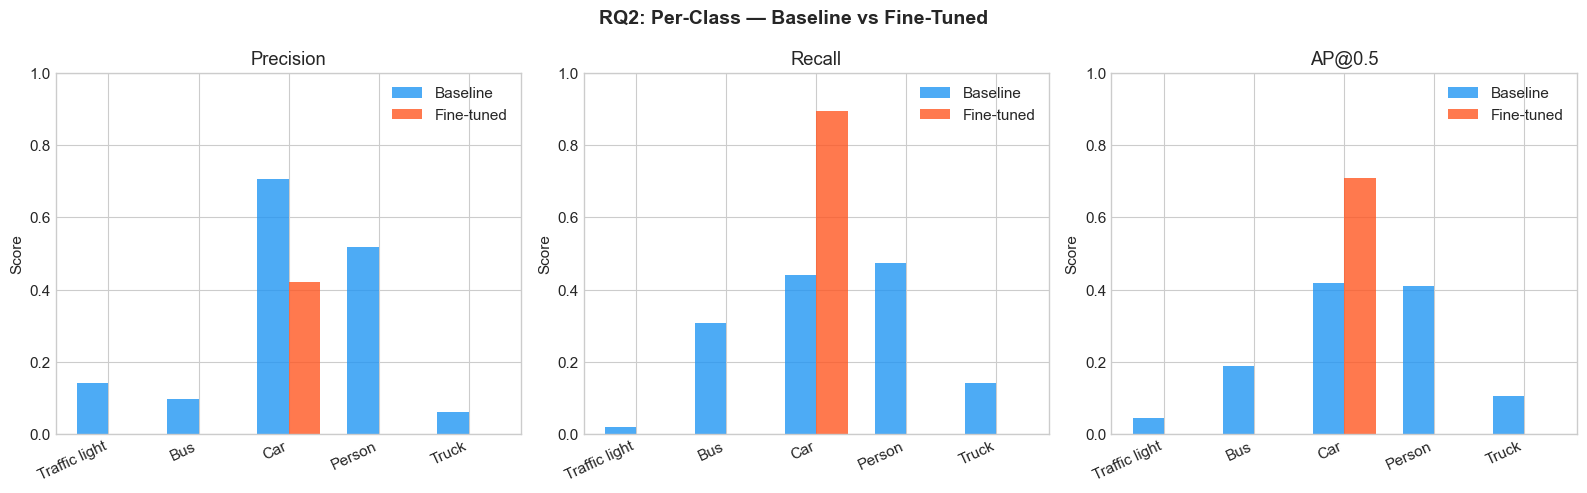

In [21]:
# Per-class comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cn=[r['class'] for r in bl_res['per_class']]; x=np.arange(len(cn)); w=0.35

for ax, metric, title in zip(axes, ['P','R','AP'], ['Precision','Recall','AP@0.5']):
    bv=[r[metric] for r in bl_res['per_class']]; fv=[r[metric] for r in ft_res['per_class']]
    ax.bar(x-w/2, bv, w, label='Baseline', color='#2196F3', alpha=0.8)
    ax.bar(x+w/2, fv, w, label='Fine-tuned', color='#FF5722', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(cn, rotation=25, ha='right')
    ax.set_ylabel('Score'); ax.set_title(title); ax.legend(); ax.set_ylim(0,1)

plt.suptitle('RQ2: Per-Class — Baseline vs Fine-Tuned', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/rq2_per_class_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

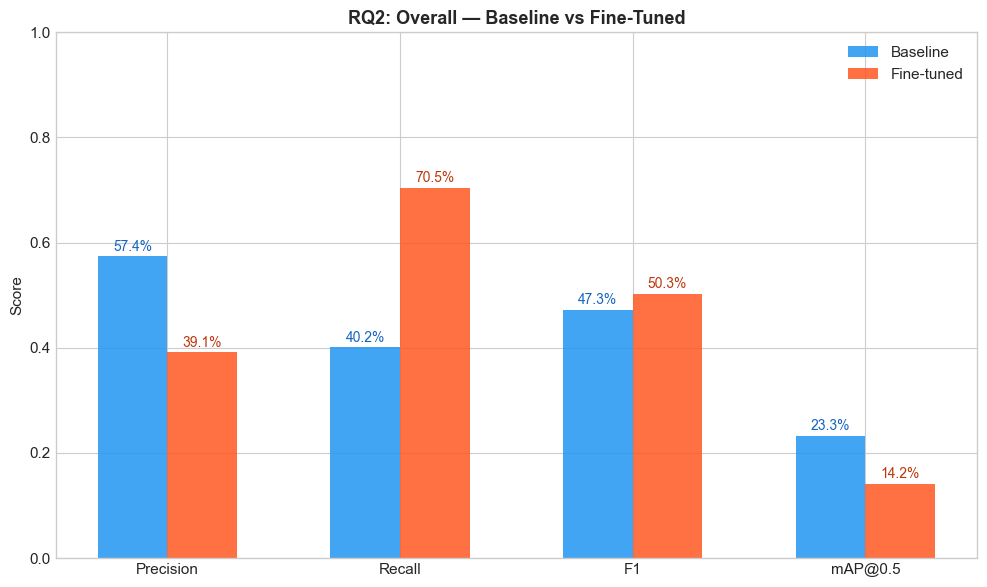

In [22]:
# Overall comparison
fig, ax = plt.subplots(figsize=(10, 6))
ms=['P','R','F1','mAP']; ml=['Precision','Recall','F1','mAP@0.5']
bv=[b[m] for m in ms]; fv=[f[m] for m in ms]; x=np.arange(len(ms)); w=0.3
bars1=ax.bar(x-w/2,bv,w,label='Baseline',color='#2196F3',alpha=0.85)
bars2=ax.bar(x+w/2,fv,w,label='Fine-tuned',color='#FF5722',alpha=0.85)
for bar,v in zip(bars1,bv): ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,f'{v:.1%}',ha='center',fontsize=10,color='#1565C0')
for bar,v in zip(bars2,fv): ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,f'{v:.1%}',ha='center',fontsize=10,color='#BF360C')
ax.set_xticks(x); ax.set_xticklabels(ml); ax.set_ylabel('Score')
ax.set_title('RQ2: Overall — Baseline vs Fine-Tuned', fontsize=13, fontweight='bold')
ax.legend(); ax.set_ylim(0,1)
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/rq2_overall_comparison.png',dpi=150,bbox_inches='tight'); plt.show()

## 10. Confidence Threshold Comparison

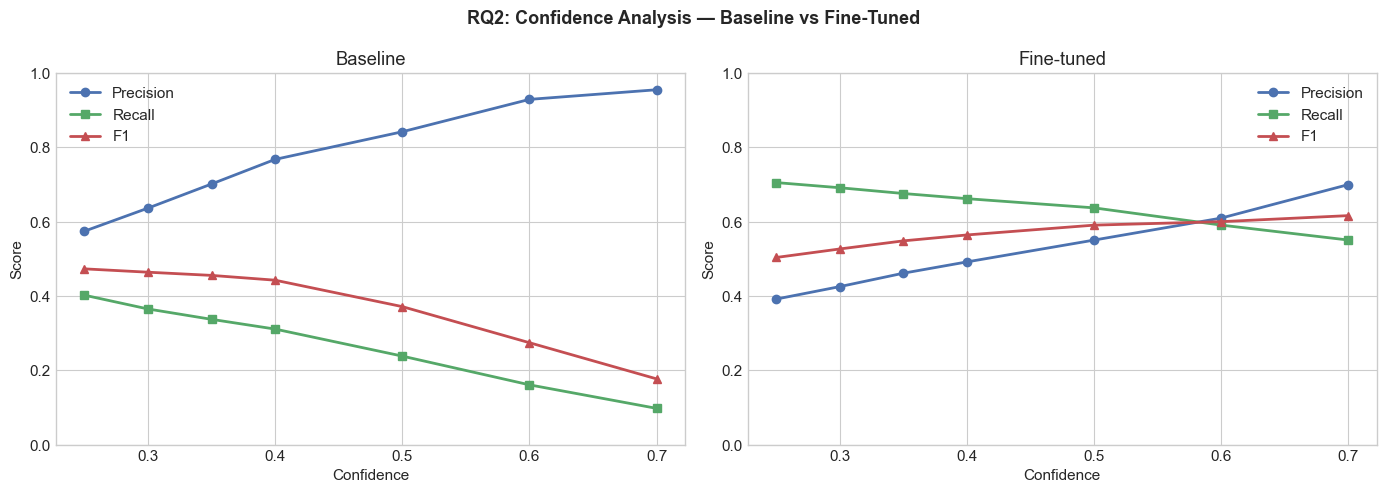

In [25]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(14,5))
bc=bl_res['conf']; fc=ft_res['conf']; th=[c['thr'] for c in bc]
for ax,data,title in [(a1,bc,'Baseline'),(a2,fc,'Fine-tuned')]:
    ax.plot(th,[c['P'] for c in data],'b-o',label='Precision',lw=2)
    ax.plot(th,[c['R'] for c in data],'g-s',label='Recall',lw=2)
    ax.plot(th,[c['F1'] for c in data],'r-^',label='F1',lw=2)
    ax.set_xlabel('Confidence'); ax.set_ylabel('Score'); ax.set_title(title); ax.legend(); ax.set_ylim(0,1)
plt.suptitle('RQ2: Confidence Analysis — Baseline vs Fine-Tuned',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/rq2_confidence.png',dpi=150,bbox_inches='tight'); plt.show()

## 11. Training Curves

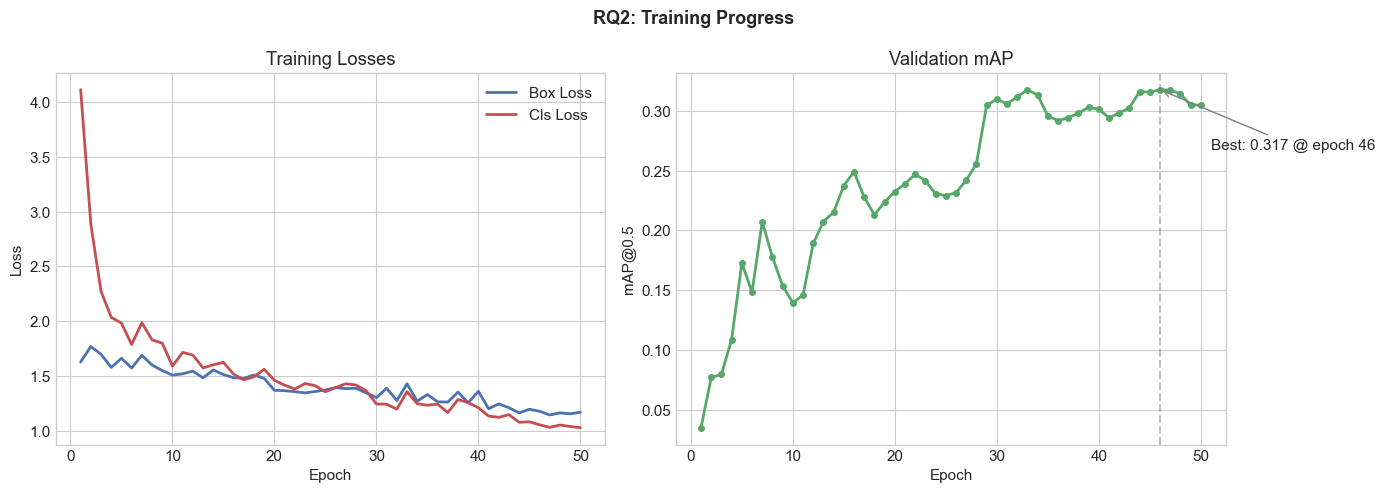

In [26]:
train_csv = f'../runs/detect/{RUN_NAME}/results.csv'
if os.path.exists(train_csv):
    epochs_n,bloss,closs,vmap=[],[],[],[]
    with open(train_csv) as ff:
        reader=csv.DictReader(ff)
        for row in reader:
            row={k.strip():v.strip() for k,v in row.items()}
            epochs_n.append(int(row.get('epoch',0))); bloss.append(float(row.get('train/box_loss',0)))
            closs.append(float(row.get('train/cls_loss',0))); vmap.append(float(row.get('metrics/mAP50(B)',0)))
    fig,(a1,a2)=plt.subplots(1,2,figsize=(14,5))
    a1.plot(epochs_n,bloss,'b-',label='Box Loss',lw=2); a1.plot(epochs_n,closs,'r-',label='Cls Loss',lw=2)
    a1.set_xlabel('Epoch'); a1.set_ylabel('Loss'); a1.set_title('Training Losses'); a1.legend()
    a2.plot(epochs_n,vmap,'g-o',lw=2,ms=4); a2.set_xlabel('Epoch'); a2.set_ylabel('mAP@0.5'); a2.set_title('Validation mAP')
    be=epochs_n[np.argmax(vmap)]; bm=max(vmap)
    a2.axvline(x=be,color='gray',ls='--',alpha=0.5)
    a2.annotate(f'Best: {bm:.3f} @ epoch {be}',xy=(be,bm),xytext=(be+5,bm-0.05),arrowprops=dict(arrowstyle='->',color='gray'))
    plt.suptitle('RQ2: Training Progress',fontsize=13,fontweight='bold')
    plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/rq2_training_curves.png',dpi=150,bbox_inches='tight'); plt.show()
else:
    print(f'Training CSV not found: {train_csv}')

## 12. Save Results

In [27]:
with open(f'{RESULTS_DIR}/rq2_comparison.csv','w',newline='') as ff:
    w=csv.writer(ff); w.writerow(['metric','baseline','finetuned','change'])
    for m in ['P','R','F1','mAP']:
        w.writerow([m,b[m],f[m],round(f[m]-b[m],4)])
with open(f'{RESULTS_DIR}/rq2_per_class.csv','w',newline='') as ff:
    w=csv.writer(ff); w.writerow(['class','base_P','base_R','base_AP','ft_P','ft_R','ft_AP','delta_AP'])
    for bc,fc in zip(bl_res['per_class'],ft_res['per_class']):
        w.writerow([bc['class'],bc['P'],bc['R'],bc['AP'],fc['P'],fc['R'],fc['AP'],round(fc['AP']-bc['AP'],4)])
print('All RQ2 results saved.')

All RQ2 results saved.


## RQ2 Summary

### Answer:
Fine-tuning on 104 Newcastle images **significantly improved car detection** 
(AP: 41.7% → 70.9%) and **overall recall** (40.2% → 70.5%) but caused 
**catastrophic forgetting** on minority classes.

### Key findings:
1. Car AP improved by +29.2% — validates domain adaptation approach
2. Car recall jumped from 44.1% to 89.4% — model finds most visible cars
3. Overall F1 improved from 47.3% to 50.3%
4. Bus, truck, person, traffic light degraded due to class imbalance (only 10 bus, 9 truck labels in training)
5. At conf≥0.7, fine-tuned achieves 69.9% precision, 55.0% recall

### Future work:
- Class-balanced sampling / oversampling minority classes
- Freeze backbone layers to reduce forgetting
- Collect more training data for underrepresented classes
- Use larger model (YOLOv8s) for better small object detection

**Proceed to RQ3 for the urban activity score.**